# Data processing

## *Preprocessing, representation & feature engineering*

## Objetivo de la clase

Los datos rara vez llegan en una forma directamente utilizable por un modelo de Machine Learning.

En esta clase vamos a recorrer un pipeline práctico:

**datos crudos → limpieza → transformación → representación → nuevas features → modelo**

La idea central es distinguir dos objetivos:

- **Preprocesado:** hacer que los datos sean compatibles y manejables para el modelo.
- **Feature engineering:** construir representaciones que expresen mejor la información disponible y faciliten el aprendizaje.

> **Regla de oro:** todas las transformaciones que "aprenden" algo de los datos deben ajustarse con **train** y luego aplicarse a validation/test. Nunca debemos usar información del futuro o del conjunto de test para construir features.


# 1. ¿Por qué necesitamos preprocesar?

Los datos reales pueden tener:

- valores faltantes;
- errores y outliers;
- filas duplicadas;
- variables en escalas muy diferentes;
- categorías;
- texto;
- fechas;
- información redundante;
- información útil escondida dentro de una misma columna.

Además, distintos modelos tienen distintas necesidades.

Por ejemplo:

- un árbol de decisión puede tolerar escalas diferentes;
- una regresión logística o una red neuronal suele beneficiarse del escalado;
- un modelo no puede interpretar directamente `"Argentina"` como una variable numérica;
- un modelo no sabe automáticamente que `2026-08-09 20:00` contiene información como día de semana, mes u hora.

**Preprocesar no es "hacer magia": es representar los datos de una forma adecuada para el problema y el modelo.**


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder, OrdinalEncoder, StandardScaler,
    MinMaxScaler, QuantileTransformer, PolynomialFeatures
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error

#plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)


# 2. Valores nulos: MCAR, MAR y MNAR

Un valor nulo significa que **no observamos el dato**, no necesariamente que el dato "no exista".

### MCAR — Missing Completely At Random

La probabilidad de que falte un dato no depende ni del valor faltante ni de otras variables observadas.

Ejemplo: un sensor se desconecta aleatoriamente algunos días.

### MAR — Missing At Random

La probabilidad de que falte un dato depende de información que **sí observamos**.

Ejemplo: el sensor de humedad suele fallar más cuando la temperatura es baja.

### MNAR — Missing Not At Random

La probabilidad de que falte el dato depende del propio valor faltante o de información que no observamos.

Ejemplo: un sensor de viento deja de registrar justamente cuando el viento supera cierto valor.

### ¿Qué hacemos?

#### MCAR

* pocos missing → eliminar filas
* muchos missing → imputación simple
* generalmente menor riesgo de sesgo

#### MAR

* imputar usando otras variables observadas
* agregar indicador de missing cuando tenga sentido
* evitar imputar usando información que no estaría disponible en producción

#### MNAR

* primero intentar entender por qué falta
* indicador de missing puede ser útil
* la imputación simple puede introducir sesgo
* requiere supuestos adicionales / métodos específicos

La pregunta más importante no es **"¿cómo imputo?"** sino **"¿por qué falta este dato?"**

💡 **Idea clave:** imputar no "recupera" mágicamente el dato real; introduce una estimación.


In [4]:
df = pd.DataFrame({
    "edad": [25, 31, np.nan, 45, 52, np.nan],
    "ingresos": [1000, 1800, 1500, np.nan, 5000, 2200],
    "ciudad": ["A", "A", "B", "B", np.nan, "A"]
})
df


,edad,ingresos,ciudad
0,25.0,1000.0,A
1,31.0,1800.0,A
2,NaN,1500.0,B
3,45.0,NaN,B
4,52.0,5000.0,NaN
5,NaN,2200.0,A


In [5]:
# Ejemplo simple de imputación.
# En un proyecto real, el imputador se ajusta SOLO con train.
numeric_imputer = SimpleImputer(strategy="median")
categorical_imputer = SimpleImputer(strategy="most_frequent")

df_num = pd.DataFrame(
    numeric_imputer.fit_transform(df[["edad", "ingresos"]]),
    columns=["edad", "ingresos"]
)
df_cat = pd.DataFrame(
    categorical_imputer.fit_transform(df[["ciudad"]]),
    columns=["ciudad"]
)

pd.concat([df_num, df_cat], axis=1)


,edad,ingresos,ciudad
0,25.0,1000.0,A
1,31.0,1800.0,A
2,38.0,1500.0,B
3,45.0,1800.0,B
4,52.0,5000.0,A
5,38.0,2200.0,A


# 3. Datos redundantes y duplicados

## Datos redundantes

Son columnas que contienen información repetida o casi repetida.

Ejemplos:

- `precio_usd` y `precio_pesos` junto con un tipo de cambio fijo;
- `fecha_nacimiento` y `edad` si la edad ya fue calculada para una fecha determinada;
- una variable y una transformación determinística de la misma.

No toda correlación implica que una columna sea redundante, pero la redundancia puede:

- aumentar la complejidad;
- dificultar la interpretación;
- generar problemas de multicolinealidad en algunos modelos;
- aumentar costo de procesamiento.

## Filas duplicadas

Son ejemplos repetidos.

Son especialmente peligrosas cuando hacemos el split después de duplicar: el mismo ejemplo puede terminar en **train y test**, produciendo métricas artificialmente buenas.

**Antes de entrenar:** revisar `duplicated()`, claves únicas y reglas de negocio.


In [6]:
example = pd.DataFrame({
    "cliente": [1, 2, 2, 3],
    "edad": [30, 40, 40, 25],
    "compra": [100, 200, 200, 80]
})

print("Duplicados:")
display(example[example.duplicated(keep=False)])

print("\nDataset sin duplicados:")
display(example.drop_duplicates())


Duplicados:


,cliente,edad,compra
1,2,40,200
2,2,40,200



Dataset sin duplicados:


,cliente,edad,compra
0,1,30,100
1,2,40,200
3,3,25,80


# 4. Variables categóricas

Una categoría no es necesariamente un número.

Si tenemos:

`país = ["Argentina", "Brasil", "Chile"]`

no tiene sentido asignar:

`Argentina = 1, Brasil = 2, Chile = 3`

porque el número introduce una relación de orden y distancia que no existe.

Vamos a ver cuatro ideas:

1. **One-hot encoding**
2. **Ordinal encoding**
3. **Target encoding**
4. **Categorical embeddings**

Lib con varias tecnicas implementadas: [Category encoders](https://contrib.scikit-learn.org/category_encoders/)

## One-hot encoding

Cada categoría se convierte en una columna binaria.

| país | Argentina | Brasil | Chile |
|---|---:|---:|---:|
| Argentina | 1 | 0 | 0 |
| Brasil | 0 | 1 | 0 |
| Chile | 0 | 0 | 1 |

Es simple, interpretable y suele ser una excelente primera opción.

Problema: si tenemos miles o millones de categorías, podemos terminar con una representación enorme.


In [8]:
cities = pd.DataFrame({
    "ciudad": ["Rafaela", "Rosario", "Buenos Aires", "Rafaela", "Rosario"]
})

ohe = OneHotEncoder(sparse=False, handle_unknown="ignore")
encoded = ohe.fit_transform(cities[["ciudad"]])

pd.DataFrame(encoded, columns=ohe.get_feature_names_out(["ciudad"]))


,ciudad_Buenos Aires,ciudad_Rafaela,ciudad_Rosario
0,0.0,1.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,0.0
3,0.0,1.0,0.0
4,0.0,0.0,1.0


## Ordinal encoding

Asigna un número a cada categoría.

Tiene sentido cuando existe un **orden real**:

`bajo < medio < alto`

No necesariamente tiene sentido para:

`Argentina, Brasil, Chile`

porque ahí el número sería arbitrario.



In [9]:
levels = pd.DataFrame({"nivel": ["bajo", "medio", "alto", "medio", "bajo"]})

ordinal = OrdinalEncoder(categories=[["bajo", "medio", "alto"]])
levels["nivel_encoded"] = ordinal.fit_transform(levels[["nivel"]])

levels


,nivel,nivel_encoded
0,bajo,0.0
1,medio,1.0
2,alto,2.0
3,medio,1.0
4,bajo,0.0


## Target encoding

En lugar de representar una categoría como una columna binaria, la representamos usando información del **target**.

Ejemplo conceptual para regresión:

- categoría A → target promedio 120
- categoría B → target promedio 80
- categoría C → target promedio 150

Esto puede ser muy útil cuando hay muchas categorías.

### El gran peligro: leakage

Si calculamos el promedio de cada categoría usando todo el dataset antes del split, estamos usando información del target de test.

En la práctica se utilizan técnicas de smoothing y/o esquemas out-of-fold.

💡 **Idea clave:** entender la idea y el riesgo de leakage es más importante que memorizar una implementación.


## ¿Qué es un embedding?

Un **embedding** es una representación de un objeto mediante un **vector de números**.

La idea es transformar:

**objeto → representación numérica**

buscando que objetos similares tengan representaciones similares.

Por ejemplo, podríamos representar algunas palabras en un espacio de 3 dimensiones:

```text
"gato"  → [0.8, 0.2, 0.7]
"perro" → [0.7, 0.3, 0.8]
"auto"  → [0.1, 0.9, 0.2]
```

Intuitivamente, gato y perro podrían quedar más cerca entre sí que gato y auto.

💡 **Idea clave:** los números individuales no tienen necesariamente un significado interpretable. Lo importante es la posición relativa de los vectores en el espacio.

In [10]:
embeddings = {
    "gato":  [0.8, 0.2],
    "perro": [0.7, 0.3],
    "auto":  [0.1, 0.9],
    "avión": [0.2, 0.8],
}

for word, vector in embeddings.items():
    print(f"{word:>6} → {vector}")

  gato → [0.8, 0.2]
 perro → [0.7, 0.3]
  auto → [0.1, 0.9]
 avión → [0.2, 0.8]


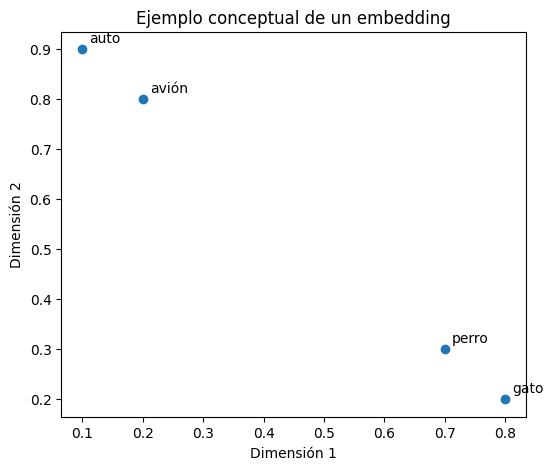

In [11]:
import matplotlib.pyplot as plt

words = list(embeddings.keys())
vectors = np.array(list(embeddings.values()))

plt.figure(figsize=(6, 5))

plt.scatter(vectors[:, 0], vectors[:, 1])

for word, (x, y) in zip(words, vectors):
    plt.annotate(word, (x, y), xytext=(5, 5), textcoords="offset points")

plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.title("Ejemplo conceptual de un embedding")
plt.show()

## Categorical embeddings

Una categoría también puede representarse mediante un **embedding**.

En lugar de representar:

```text
Argentina → [1, 0, 0]
Brasil    → [0, 1, 0]
Japón     → [0, 0, 1]
```

podemos aprender una representación densa:

```text
Argentina → [ 0.23, -0.41,  0.78]
Brasil    → [ 0.19, -0.35,  0.71]
Japón     → [-0.62,  0.83, -0.12]
```

💡 **Idea clave** un embedding no es simplemente *"asignarle números a una categoría"*. Es una representación vectorial **aprendida por el modelo.**

## Comparación

| Representación | Ejemplo               |            Dimensión | ¿Se aprende? |
| -------------- | --------------------- | -------------------: | -----------: |
| One-hot        | `[0, 1, 0, 0, 0]`     |     Nº de categorías |            ❌ |
| Ordinal        | `2`                   |                    1 |            ❌ |
| Embedding      | `[0.21, -0.43, 0.17]` | Elegida por nosotros |            ✅ |

# 5. Variables numéricas

En variables numéricas aparecen tres problemas frecuentes:

- outliers;
- escalas muy diferentes;
- distribuciones difíciles para determinados modelos.



## Outliers

Un outlier es una observación muy alejada del resto.

Pero **outlier ≠ error**.

Antes de eliminarlo hay que preguntar:

> ¿Es un dato incorrecto o es un caso real pero poco frecuente?

Ejemplos:

- edad = 250 → probablemente error;
- ingreso = $10.000.000 → puede ser perfectamente real.

Eliminar outliers automáticamente puede eliminar justamente los casos que queremos aprender.


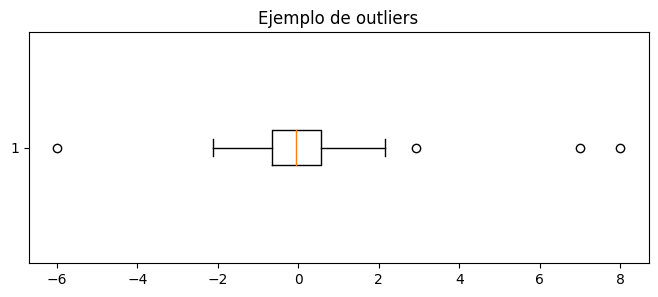

In [12]:
rng = np.random.default_rng(42)
x = np.concatenate([rng.normal(0, 1, 200), [7, 8, -6]])

plt.figure(figsize=(8, 3))
plt.boxplot(x, vert=False)
plt.title("Ejemplo de outliers")
plt.show()


## Escalado

Supongamos que tenemos:

- edad: 20–80
- ingresos: 0–100000
- cantidad de compras: 0–20

En modelos basados en distancias, gradientes o magnitudes, una variable puede dominar a las demás simplemente por su escala.

### Algunas transformaciones

**Min-Max**

Lleva los valores normalmente a `[0, 1]`.

**Standardization**

Lleva la media a 0 y el desvío estándar a 1.

**Mean normalization**

Centra respecto de la media.

La elección depende del modelo y del problema.

> Los árboles de decisión y modelos basados en splits suelen ser mucho menos sensibles al escalado que modelos lineales, k-NN o redes neuronales.


In [13]:
X = pd.DataFrame({
    "edad": [20, 30, 40, 50, 60],
    "ingresos": [1000, 5000, 10000, 50000, 100000]
})

standard = StandardScaler()
X_standard = pd.DataFrame(
    standard.fit_transform(X),
    columns=X.columns
)

minmax = MinMaxScaler()
X_minmax = pd.DataFrame(
    minmax.fit_transform(X),
    columns=X.columns
)

display(X_standard)
display(X_minmax)


,edad,ingresos
0,-1.414214,-0.853610
1,-0.707107,-0.747572
2,0.000000,-0.615023
3,0.707107,0.445362
4,1.414214,1.770843


,edad,ingresos
0,0.00,0.000000
1,0.25,0.040404
2,0.50,0.090909
3,0.75,0.494949
4,1.00,1.000000


## Quantile transformation

La transformación por cuantiles re-mapea los valores según su posición en la distribución.

Puede producir:

- una distribución aproximadamente **uniforme**;
- o una distribución aproximadamente **normal**.

Es particularmente interesante cuando la variable tiene una distribución muy sesgada y queremos reducir la influencia de valores extremos.



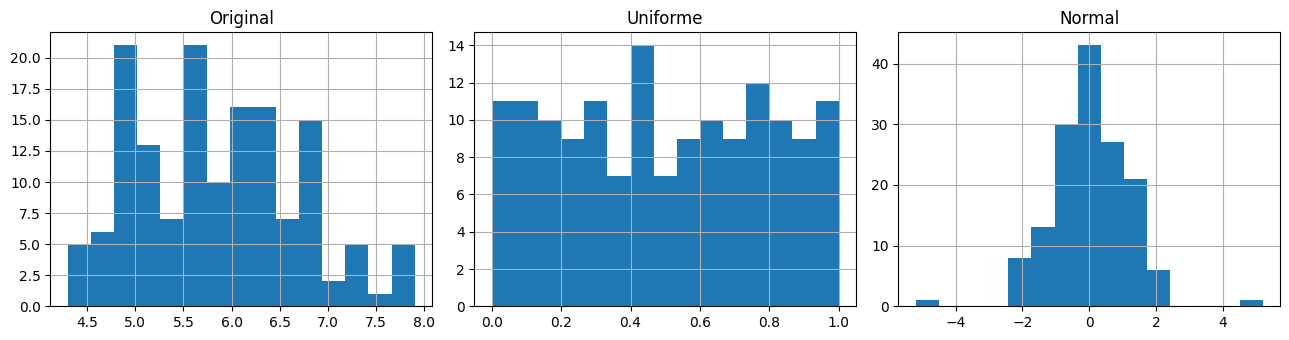

In [14]:
iris = load_iris(as_frame=True)
x = iris.data[["sepal length (cm)"]]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

x.iloc[:, 0].hist(ax=axes[0], bins=15)
axes[0].set_title("Original")

qt_uniform = QuantileTransformer(
    n_quantiles=min(50, len(x)),
    output_distribution="uniform",
    random_state=42
)
x_uniform = qt_uniform.fit_transform(x)
pd.Series(x_uniform.ravel()).hist(ax=axes[1], bins=15)
axes[1].set_title("Uniforme")

qt_normal = QuantileTransformer(
    n_quantiles=min(50, len(x)),
    output_distribution="normal",
    random_state=42
)
x_normal = qt_normal.fit_transform(x)
pd.Series(x_normal.ravel()).hist(ax=axes[2], bins=15)
axes[2].set_title("Normal")

plt.tight_layout()


> 🚀 **Técnicas avanzadas:** AutoDis, PLE y otras técnicas de *representation learning* permiten aprender automáticamente representaciones más sofisticadas de las features.

# 6. Texto

El texto introduce otro problema:

> Una frase no es directamente una matriz de números.

Podemos representar texto con distintos niveles de sofisticación.

### Count Vectorizer

Construye una columna por palabra/token y cuenta ocurrencias.

Ejemplo:

`"gato perro gato"`

→ `gato=2, perro=1`

Es simple, rápido y muy útil como baseline.

### Tokenización

Antes de representar texto necesitamos decidir cuáles son los "tokens":

- palabras;
- subwords;
- caracteres;
- etc.

Los tokenizers modernos, especialmente en NLP con Transformers, suelen trabajar con subwords.

### Embeddings

Cada token puede representarse como un vector denso.

Una aproximación muy simple para obtener un vector del documento es hacer el **promedio de los embeddings de sus tokens**.

💡 **Idea clave:** Es útil pero pierde información sobre orden y contexto.


In [15]:
documents = [
    "gato juega en casa",
    "perro juega en casa",
    "gato duerme",
    "perro corre en parque"
]

vectorizer = CountVectorizer()
X_text = vectorizer.fit_transform(documents)

count_df = pd.DataFrame(
    X_text.toarray(),
    columns=vectorizer.get_feature_names_out()
)

count_df


,casa,corre,duerme,en,gato,juega,parque,perro
0,1,0,0,1,1,1,0,0
1,1,0,0,1,0,1,0,1
2,0,0,1,0,1,0,0,0
3,0,1,0,1,0,0,1,1


## Mean of embeddings — idea conceptual

Si tenemos:

- `gato → e_gato`
- `juega → e_juega`
- `casa → e_casa`

podemos construir:

`embedding(documento) = mean(e_gato, e_juega, e_casa)`

Esto transforma una cantidad variable de tokens en un vector de tamaño fijo.

La representación es sencilla, pero tiene una limitación importante: dos frases con las mismas palabras pueden terminar con representaciones muy parecidas aunque el orden cambie.

Los modelos modernos de lenguaje aprenden representaciones contextuales mucho más ricas.


In [17]:
embeddings = {
    "gato": np.array([1.0, 0.0, 0.5]),
    "juega": np.array([0.2, 0.8, 0.1]),
    "casa": np.array([0.4, 0.1, 0.9]),
}

tokens = ["gato", "juega", "casa"]
document_embedding = np.mean([embeddings[t] for t in tokens], axis=0)

document_embedding


array([0.53333333, 0.3       , 0.5       ])

# 7. Feature engineering: hacer los datos más expresivos

La diferencia práctica:

- **Preprocesado:** "¿cómo hago que el modelo pueda usar este dato?"
- **Feature engineering:** "¿cómo puedo representar este problema de una forma que le resulte más fácil de aprender?"

No existe una lista cerrada de técnicas.

Es un proceso iterativo:

**idea → feature → modelo → evaluación → nueva idea**



## 7.1 Extraer información escondida

Una columna puede contener varias piezas de información.

Ejemplo:

`datetime = 2026-08-09 20:35`

Podemos extraer:

- año;
- mes;
- día;
- día de semana;
- hora;
- fin de semana;
- etc.

Esto evita pedirle al modelo que descubra por sí mismo una relación que nosotros conocemos.


In [18]:
dates = pd.DataFrame({
    "fecha": pd.to_datetime([
        "2026-08-03 09:30",
        "2026-08-08 20:15",
        "2026-08-09 12:00"
    ])
})

dates["año"] = dates["fecha"].dt.year
dates["mes"] = dates["fecha"].dt.month
dates["dia_semana"] = dates["fecha"].dt.dayofweek
dates["hora"] = dates["fecha"].dt.hour
dates["fin_de_semana"] = (dates["dia_semana"] >= 5).astype(int)

dates


,fecha,año,mes,dia_semana,hora,fin_de_semana
0,2026-08-03 09:30:00,2026,8,0,9,0
1,2026-08-08 20:15:00,2026,8,5,20,1
2,2026-08-09 12:00:00,2026,8,6,12,1


## 7.2 Features no lineales e interacciones

Un modelo lineal aprende algo de la forma:

`y = a·x + b`

Pero un problema puede depender de:

`y = a·x² + b`

o de una interacción:

`y = a·x1·x2 + b`

Podemos crear explícitamente esas variables.



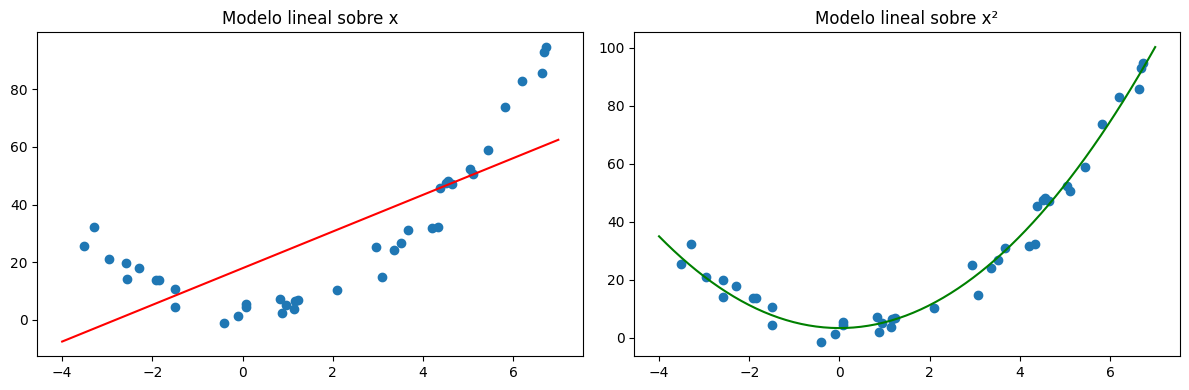

In [19]:
def plot_linear_vs_quadratic():
    rng = np.random.default_rng(42)
    x = rng.uniform(-4, 7, size=40)
    y = 2 * x**2 + 3 + rng.normal(0, 5, size=len(x))
    grid = np.linspace(-4, 7, 200)

    linear = LinearRegression().fit(x.reshape(-1, 1), y)
    quadratic = LinearRegression().fit((x**2).reshape(-1, 1), y)

    pred_linear = linear.predict(grid.reshape(-1, 1))
    pred_quadratic = quadratic.predict((grid**2).reshape(-1, 1))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].scatter(x, y)
    axes[0].plot(grid, pred_linear, color="red")
    axes[0].set_title("Modelo lineal sobre x")

    axes[1].scatter(x, y)
    axes[1].plot(grid, pred_quadratic, color="green")
    axes[1].set_title("Modelo lineal sobre x²")

    plt.tight_layout()

plot_linear_vs_quadratic()


## 7.3 Features agregadas en el tiempo

Esta es una de las técnicas más poderosas en datos tabulares temporales.

Si tenemos ventas:

| fecha | cliente | importe |
|---|---|---:|
| lunes | A | 100 |
| martes | A | 200 |
| miércoles | A | 50 |

para una nueva venta del cliente A podemos crear:

- cantidad de compras anteriores;
- suma histórica;
- promedio histórico;
- días desde la última compra;
- promedio de los últimos 7 días;
- etc.

### El gran peligro: data leakage

Cuando generamos una feature para una observación, solo podemos utilizar información que **habría estado disponible en ese momento**.

Nunca:

`promedio de todas las ventas del cliente`

si estamos intentando predecir una venta que todavía no ocurrió.

Sí:

`promedio de las ventas anteriores a esta venta`.


In [20]:
sales = pd.DataFrame({
    "cliente": ["A", "A", "A", "B", "B"],
    "fecha": pd.to_datetime([
        "2026-01-01", "2026-01-03", "2026-01-05",
        "2026-01-02", "2026-01-06"
    ]),
    "importe": [100, 200, 50, 300, 100]
}).sort_values(["cliente", "fecha"])

# Promedio histórico SIN incluir la observación actual.
sales["promedio_historico"] = (
    sales.groupby("cliente")["importe"]
         .transform(lambda s: s.shift(1).expanding().mean())
)

sales["cantidad_compras_previas"] = (
    sales.groupby("cliente").cumcount()
)

sales


,cliente,fecha,importe,promedio_historico,cantidad_compras_previas
0,A,2026-01-01,100,NaN,0
1,A,2026-01-03,200,100.0,1
2,A,2026-01-05,50,150.0,2
3,B,2026-01-02,300,NaN,0
4,B,2026-01-06,100,300.0,1


# 8. Un ejemplo de pipeline completo

En un proyecto real no queremos hacer transformaciones manualmente y después olvidarnos de qué hicimos.

Una buena práctica es construir un **pipeline reproducible**:

1. separar train/test;
2. definir transformaciones por tipo de variable;
3. ajustar transformaciones con train;
4. aplicar las mismas transformaciones a validation/test;
5. entrenar el modelo.



In [21]:
data = pd.DataFrame({
    "edad": [22, 35, 42, 28, 51, 46, 31, 39],
    "ingresos": [1200, 3000, 5000, 1800, 9000, 7000, 2500, 4200],
    "ciudad": ["A", "B", "A", "C", "B", "A", "C", "B"],
    "compra": [0, 1, 1, 0, 1, 1, 0, 1]
})

X = data.drop(columns="compra")
y = data["compra"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

numeric_features = ["edad", "ingresos"]
categorical_features = ["ciudad"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression())
])

model.fit(X_train, y_train)
print("Accuracy:", model.score(X_test, y_test))


Accuracy: 1.0


# 9. Resumen: ¿qué técnica usar?

| Problema | Primera opción |
|---|---|
| Valores faltantes | Imputación + indicador de missing cuando tenga sentido |
| Filas duplicadas | Detectar y eliminar según reglas del negocio |
| Categoría nominal | One-hot |
| Categoría ordinal | Ordinal encoding |
| Categorías en general | Target encoding / embeddings |
| Variable numérica con escalas distintas | StandardScaler / MinMaxScaler según el caso |
| Distribución muy sesgada | Quantile transformation u otra transformación apropiada |
| Texto simple | CountVectorizer como baseline |
| Texto moderno | Tokenizer + embeddings |
| Fecha/hora | Extraer componentes relevantes |
| Datos temporales | Features históricas/rolling sin usar futuro |
| Modelo lineal + relación no lineal | Transformaciones/interacciones |

### Las tres preguntas que deberíamos hacernos

**1. ¿El dato está limpio?**  
Missing, errores, duplicados, inconsistencias.

**2. ¿El modelo puede consumirlo?**  
Escalado, encoding, vectorización, tokenización.

**3. ¿La representación expresa bien el problema?**  
Features temporales, agregaciones, interacciones, embeddings, etc.


# 10. Actividad

Elegí un dataset que conozcas y clasificá cada variable:

- ¿Es numérica, categórica, texto o temporal?
- ¿Tiene missing values?
- ¿Hay duplicados?
- ¿Hay outliers?
- ¿Necesita escalado?
- ¿Qué encoding usarías?
- ¿Qué información escondida podrías extraer?
- ¿Qué features históricas podrías construir?
- ¿Dónde podría aparecer data leakage?

**Objetivo:** no encontrar "la transformación correcta", sino aprender a justificar por qué una transformación puede ayudar.


# Timing sugerido para 120 minutos

| Bloque | Tiempo |
|---|---:|
| Motivación + limpieza | 15 min |
| Missing values: MCAR/MAR/MNAR | 15 min |
| Redundancia + duplicados + outliers | 10 min |
| Categóricas + embeddings | 20 min |
| Numéricas + scaling + quantile | 15 min |
| Texto | 10 min |
| Feature engineering + temporal | 20 min |
| Pipeline + discusión final | 10 min |
| **Total** | **115 min** |